In [1]:
import pandas as pd

df = pd.read_csv('fuel_prices_1970_2026.csv')
df.head()

,Date,Crude_Oil_Price
0,1970-01-01,1.21
1,1970-02-01,1.21
2,1970-03-01,1.21
3,1970-04-01,1.21
4,1970-05-01,1.21


In [2]:
df.columns

Index(['Date', 'Crude_Oil_Price'], dtype='str')

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df.head()

,Date,Crude_Oil_Price
0,1970-01-01,1.21
1,1970-02-01,1.21
2,1970-03-01,1.21
3,1970-04-01,1.21
4,1970-05-01,1.21


In [4]:
df['Year'] = df['Date'].dt.year

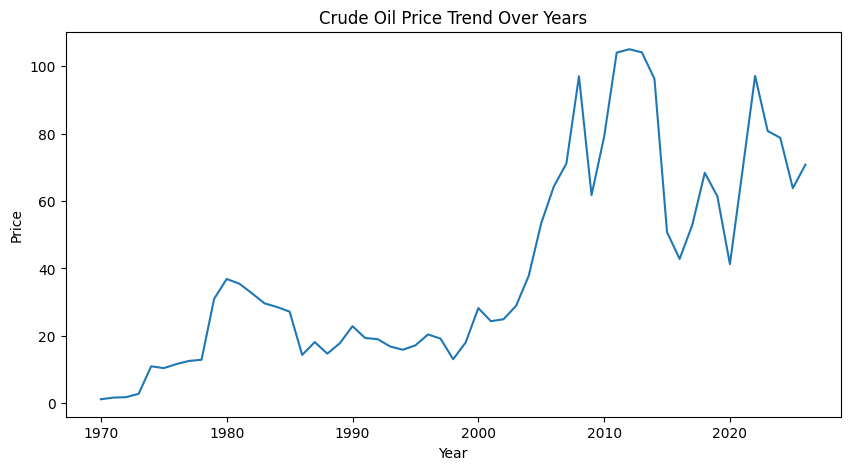

In [5]:
# Trend Analysis

import matplotlib.pyplot as plt

df.groupby('Year')['Crude_Oil_Price'].mean().plot(figsize=(10,5))

plt.title('Crude Oil Price Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

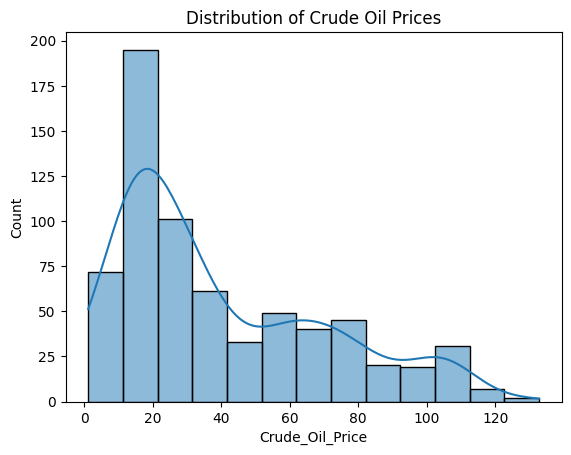

In [6]:
# Distribution Analysis (EDA)

import seaborn as sns

sns.histplot(df['Crude_Oil_Price'], kde=True)
plt.title('Distribution of Crude Oil Prices')
plt.show()

In [7]:
# Outlier Detection

Q1 = df['Crude_Oil_Price'].quantile(0.25)
Q3 = df['Crude_Oil_Price'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df['Crude_Oil_Price'] < Q1 - 1.5*IQR) | 
              (df['Crude_Oil_Price'] > Q3 + 1.5*IQR)]

outliers.head()

,Date,Crude_Oil_Price,Year
461,2008-06-01,131.521111,2008
462,2008-07-01,132.825184,2008


In [ ]:
# Forecasting

from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

yearly = df.groupby('Year')['Crude_Oil_Price'].mean().reset_index()

X = yearly[['Year']]
y = yearly['Crude_Oil_Price']

model = LinearRegression()
model.fit(X, y)

# Predict 2026 (fixed)
prediction = model.predict(pd.DataFrame({'Year': [2026]}))

print("Predicted Crude Oil Price in 2026:", prediction[0])

Predicted Crude Oil Price in 2026: 80.3789627795486


c:\Users\abhin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


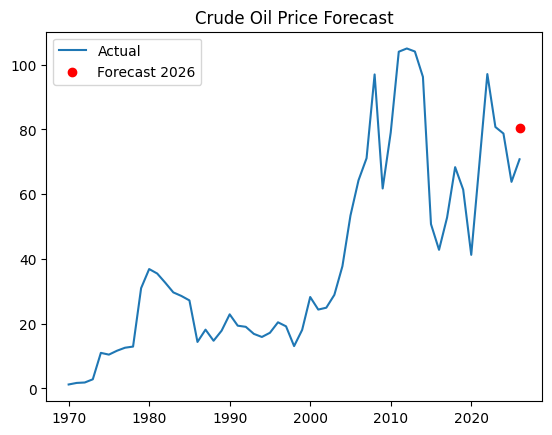

In [12]:
# Forecast Visualization

plt.plot(yearly['Year'], yearly['Crude_Oil_Price'], label='Actual')

future_year = np.array([[2026]])
future_price = model.predict(future_year)

plt.scatter(2026, future_price, color='red', label='Forecast 2026')

plt.legend()
plt.title('Crude Oil Price Forecast')
plt.show()

# Key Insights

# 1. Long-Term Price Trend

Crude oil prices show an overall upward trend over the years, indicating increasing global demand and economic growth, despite periodic fluctuations.

# 2. Price Volatility

Significant spikes and drops are observed in certain periods, reflecting the impact of global events such as economic crises, geopolitical tensions, and supply disruptions.

# 3. Distribution of Prices

The distribution of crude oil prices is right-skewed, indicating that most prices are concentrated in a lower range with occasional high-value spikes.

# 4. Outlier Detection

Outliers in the dataset represent extreme price movements, which are likely linked to major global events or market shocks.

# 5. Forecast for 2026

Using a Linear Regression model, crude oil prices are projected to follow a continued upward trend into 2026.

# 6. Model Limitation

The forecasting model used is a simple linear regression, which does not capture complex time-series patterns. More advanced models like ARIMA or Prophet could improve prediction accuracy.
